# Overview

Customer churn, or customer attrition, refers to when a customer ceases their relationship
with a company or service provider. In today's highly competitive business environment,
retaining customers is a critical factor for long-term success. Predicting customer churn can
help organizations take proactive steps to retain customers, thus minimizing revenue loss.
This project aims to build a machine learning model that can predict whether a customer will
churn based on their demographic, account, and service-related data.

# Problem Statement

The goal of this project is to develop a classification model that predicts whether a customer
will churn. Using demographic data (such as gender, senior citizen status, and tenure), along
with information about the services they use (such as internet service, phone service, and
online security), we will attempt to build a model that helps the company identify customers
who are at a high risk of churning.
By predicting customer churn, the company can proactively design retention strategies to
keep these customers, thereby improving customer satisfaction and reducing financial loss.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Data_file - data_file (1).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [4]:
# Drop the Total charges column

df = df.drop('TotalCharges', axis = 1)       

#or  one can use dropna which is a panda fucntion and is used to delete NaN rows/coloumn  "NaN = Not a Number"  
#df.dropna(subset=['TotalCharges'], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


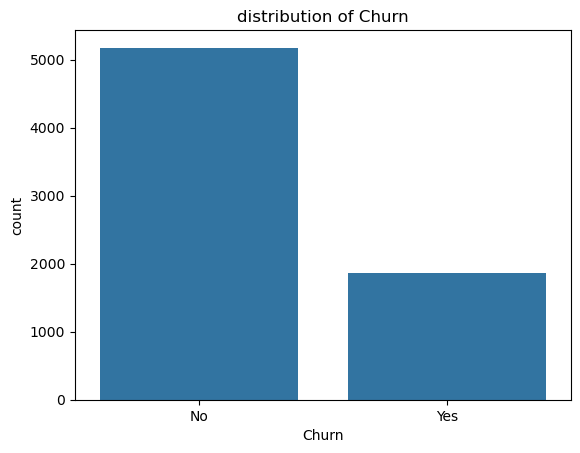

In [6]:
#distribution of target varibel

sns.countplot(x='Churn',data=df)
plt.title('distribution of Churn')
plt.show()

### Exploratory Data Analysis

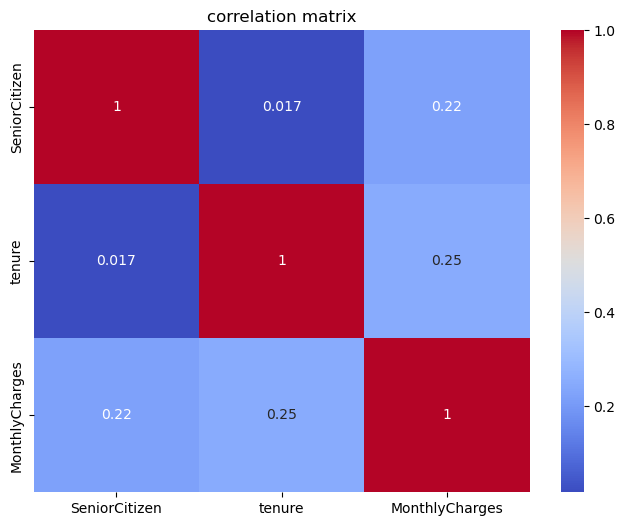

In [7]:
#correaltion matrix

num_cols= list()

for column in df.columns:
    if df[column].dtype!=object:
        num_cols.append(column)

correlation_matrix=df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

### Data Processsing

In [8]:
le = LabelEncoder()

for x in [column for column in df.columns if len(df[column].unique())==2]:
    print(x, df[x].unique())
    df[x] = le.fit_transform(df[x])

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
PaperlessBilling ['Yes' 'No']
Churn ['No' 'Yes']


In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,1


In [10]:
print(df.dtypes)

customerID           object
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
Churn                 int64
dtype: object


In [11]:
df = pd.get_dummies(df, columns = [column for column in df.columns if df[column].dtypes=='object'], drop_first=True)

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,customerID_0003-MKNFE,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,0,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,1,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,0,False,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,1,False,...,False,False,False,False,False,False,False,False,True,False


In [13]:
print(df.dtypes)

gender                                   int64
SeniorCitizen                            int64
Partner                                  int64
Dependents                               int64
tenure                                   int64
                                         ...  
Contract_One year                         bool
Contract_Two year                         bool
PaymentMethod_Credit card (automatic)     bool
PaymentMethod_Electronic check            bool
PaymentMethod_Mailed check                bool
Length: 7072, dtype: object


In [14]:
# Splitting the dataset
X = df.drop('Churn', axis = 1)
y = df['Churn']

### Logistic Regression

In [15]:
#split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [16]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

In [17]:
logreg_accuracy = accuracy_score(y_test, logreg_pred)

In [18]:
# Display accuracy and performance metrics

accuracy_percent = logreg_accuracy * 100
print("Logistic Regression Accuracy:", accuracy_percent, "%")
print('\nLogistic Regression Classification Report:')
print(classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 78.9892106757524 %

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1298
           1       0.62      0.53      0.57       463

    accuracy                           0.79      1761
   macro avg       0.73      0.71      0.72      1761
weighted avg       0.78      0.79      0.78      1761



Text(50.722222222222214, 0.5, 'Predicted')

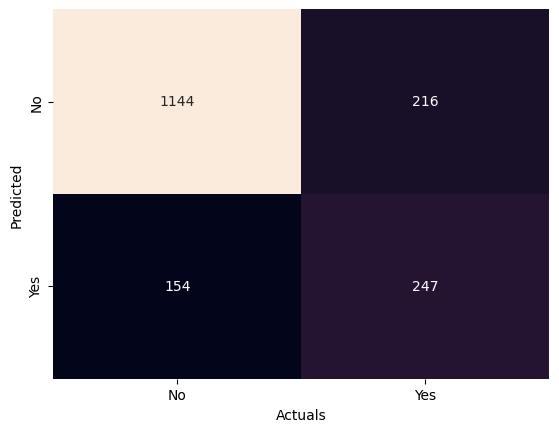

In [19]:
conf_mat = confusion_matrix(y_test, logreg_pred)
sns.heatmap(conf_mat.T, annot = True, fmt='d', cbar=False,
           xticklabels=['No', 'Yes'],
           yticklabels=['No', 'Yes'])
plt.xlabel('Actuals')
plt.ylabel('Predicted')

### KNN ALGORITHM

In [20]:
#K-nearest kneighbors
knn=KNeighborsClassifier ()
knn.fit(X_train,y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
knn_pred=knn.predict(X_test)
knn_accuracy=accuracy_score(y_test,knn_pred)

In [22]:
print(f'K-Nearest Neighbors Accuracy: {knn_accuracy * 100:.2f}%')
print('\nK-Nearest Neighbors Classification Report:')
print(classification_report(y_test, knn_pred))

K-Nearest Neighbors Accuracy: 77.46%

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1298
           1       0.58      0.53      0.55       463

    accuracy                           0.77      1761
   macro avg       0.71      0.70      0.70      1761
weighted avg       0.77      0.77      0.77      1761



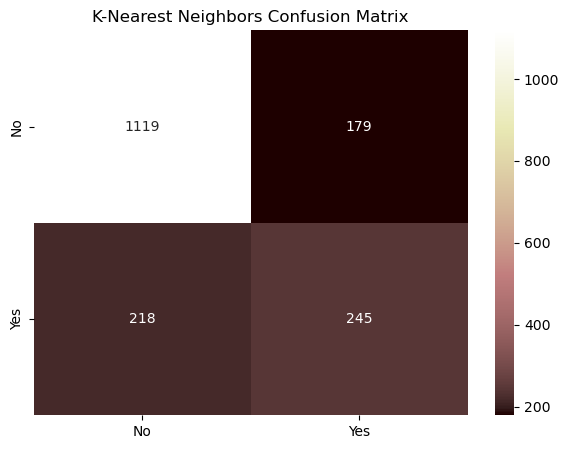

In [23]:
plt.figure(figsize=(7, 5)) 
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='pink',
           xticklabels=['No', 'Yes'],
           yticklabels=['No', 'Yes'])
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.show()

### Decision Tree Algorithm

In [24]:
decision_tree=DecisionTreeClassifier()
decision_tree.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
decision_tree_pred=decision_tree.predict(X_test)
decision_tree_accuracy=accuracy_score(y_test,decision_tree_pred)

In [26]:
print(f'decision tree Accuracy: {decision_tree_accuracy * 100:.2f}%')
print('\ndecision tree Classification Report:')
print(classification_report(y_test, decision_tree_pred))

decision tree Accuracy: 77.34%

decision tree Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1298
           1       0.57      0.53      0.55       463

    accuracy                           0.77      1761
   macro avg       0.71      0.70      0.70      1761
weighted avg       0.77      0.77      0.77      1761



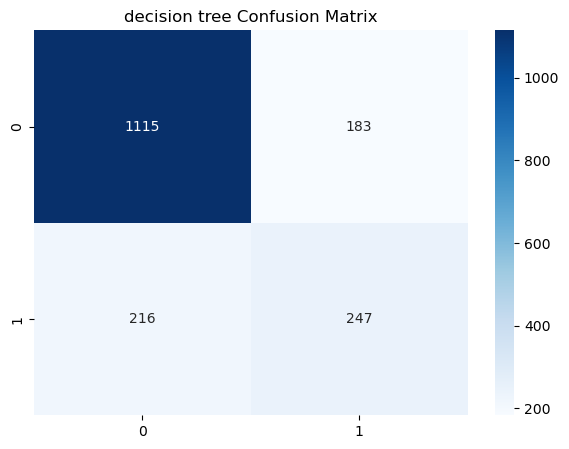

In [27]:
plt.figure(figsize=(7, 5)) 
sns.heatmap(confusion_matrix(y_test, decision_tree_pred), annot=True, fmt='d', cmap='Blues')
plt.title('decision tree Confusion Matrix')
plt.show()

### Support Vector Machine Algorithm

In [ ]:
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

In [ ]:
svm_pred =svm.predict(X_test)
svm_accuracy=accuracy_score(y_test,svm_pred)

In [ ]:
print(f'Support Vector Machine Accuracy: {svm_accuracy*100:.2f}%')
print('\nSupport Vector Machine Classification Report:')
print(classification_report(y_test, svm_pred))

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='yellow')
plt.title('Support Vector Machine Confusion Matrix')
plt.show()